In [9]:
!pip install -q kaggle "tensorflow>=2.17.0" gradio matplotlib


In [10]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [11]:
# If dataset not downloaded yet, download & unzip (comment out if already present)
import os
if not os.path.exists("/content/new-plant-diseases-dataset"):
    !kaggle datasets download -d vipoooool/new-plant-diseases-dataset -p /content
    !unzip -q /content/new-plant-diseases-dataset.zip -d /content/new-plant-diseases-dataset

# Confirm dataset presence (small print)
!ls -lah /content/new-plant-diseases-dataset | sed -n '1,200p'

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
 97% 2.61G/2.70G [00:23<00:02, 43.3MB/s]
100% 2.70G/2.70G [00:24<00:00, 120MB/s] 
total 20K
drwxr-xr-x 5 root root 4.0K Oct 30 09:04 .
drwxr-xr-x 1 root root 4.0K Oct 30 09:03 ..
drwxr-xr-x 3 root root 4.0K Oct 30 09:04 new plant diseases dataset(augmented)
drwxr-xr-x 3 root root 4.0K Oct 30 09:03 New Plant Diseases Dataset(Augmented)
drwxr-xr-x 3 root root 4.0K Oct 30 09:04 test


In [12]:
# ---------------- Python imports & config ----------------
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [13]:
# ====== User / experiment config ======
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 5
N_LAST_LAYERS = 10   # YOU PICKED: unfreeze last 10 layers
SEED = 1337

In [14]:
# ====== Dataset paths (from your environment) ======
train_dir = "/content/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train"
valid_dir = "/content/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid"

In [15]:
for p in [train_dir, valid_dir]:
    if not os.path.exists(p):
        print(f"ERROR: path not found: {p}")
        print("Run: !ls -R /content | sed -n '1,200p' to inspect files.")
        sys.exit(1)

print("train_dir:", train_dir)
print("valid_dir:", valid_dir)


train_dir: /content/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train
valid_dir: /content/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid


In [16]:
# ---------------- Data generators (Light augmentation) ----------------
# Use MobileNetV2 preprocess_input via preprocessing_function (DO NOT use rescale=1./255 together with preprocess_input)
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='reflect'
)

valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

valid_gen = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [17]:
class_names = list(train_gen.class_indices.keys())
NUM_CLASSES = len(class_names)
print("Detected classes:", NUM_CLASSES)


Detected classes: 38


In [18]:
# ---------------- Build model: MobileNetV2 backbone ----------------
from tensorflow.keras.applications import MobileNetV2

# Load pretrained backbone
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [19]:
# Freeze all then unfreeze last N_LAST_LAYERS
for layer in base_model.layers:
    layer.trainable = False

if N_LAST_LAYERS > 0:
    for layer in base_model.layers[-N_LAST_LAYERS:]:
        layer.trainable = True


In [20]:
# Assemble full model
inputs = keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)   # we already applied preprocessing in generators
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = keras.Model(inputs, outputs, name="mobilenetv2_lightaug_finetune_last10")
model.summary()

Model: "mobilenetv2_lightaug_finetune_last10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,686 (9.90 MB)

 Trainable params: 1,070,182 (4.08 MB)

 Non-trainable params: 1,525,504 (5.82 MB)

In [21]:
# ---------------- Compile ----------------
# Because some backbone layers are trainable, choose a modest learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
# ---------------- Callbacks ----------------
callbacks = [
    keras.callbacks.ModelCheckpoint("/content/mobilenetv2_best.keras", monitor='val_accuracy', save_best_only=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
]

In [23]:
# ---------------- Train (single stage: some backbone layers trainable from start) ----------------
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=valid_gen,
    callbacks=callbacks
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.6634 - loss: 1.2439
Epoch 1: val_accuracy improved from -inf to 0.91356, saving model to /content/mobilenetv2_best.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 905s 402ms/step - accuracy: 0.6635 - loss: 1.2436 - val_accuracy: 0.9136 - val_loss: 0.2938 - learning_rate: 1.0000e-04
Epoch 2/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.9190 - loss: 0.2525
Epoch 2: val_accuracy improved from 0.91356 to 0.95077, saving model to /content/mobilenetv2_best.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 854s 389ms/step - accuracy: 0.9190 - loss: 0.2524 - val_accuracy: 0.9508 - val_loss: 0.1587 - learning_rate: 1.0000e-04
Epoch 3/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.9389 - loss: 0.1887
Epoch 3: val_accuracy did not improve from 0.95077
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 843s 384ms/step - accuracy: 0.9389 - loss: 0.1887 - val_accuracy: 0.9492 - val_loss: 0.1590 - learning_rate: 1.0000e-04
Epoch 4/5
2197/2197 ━━━━

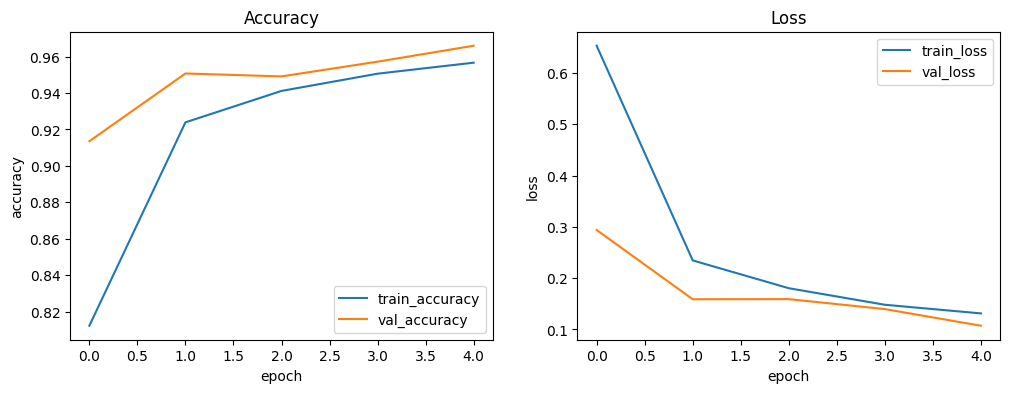

In [25]:
# ---------------- Plot training curves ----------------
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history.get('accuracy',[]), label='train_accuracy')
plt.plot(history.history.get('val_accuracy',[]), label='val_accuracy')
plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.legend(); plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history.get('loss',[]), label='train_loss')
plt.plot(history.history.get('val_loss',[]), label='val_loss')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.title('Loss')
plt.show()


In [26]:
# ---------------- Evaluate ----------------
val_loss, val_acc = model.evaluate(valid_gen)
print(f"Validation loss: {val_loss:.4f}, accuracy: {val_acc:.4f}")


550/550 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - accuracy: 0.9823 - loss: 0.0575
Validation loss: 0.1072, accuracy: 0.9660


In [27]:
# ---------------- Save final model ----------------
final_path = "/content/mobilenetv2_final.keras"
model.save(final_path)
print("Saved final model to:", final_path)

Saved final model to: /content/mobilenetv2_final.keras
